# XAU/USD Direction Classifier — Model Analysis

## Objective

This notebook analyzes the final trained classification model to understand its performance across different market conditions.

The analysis focuses on:

- Overall model performance
- Performance across different years
- Performance across trading hours
- Performance across days of the week
- Performance under different volatility conditions
- Prediction confidence analysis
- Model error analysis

The model was selected using time-series cross-validation and evaluated on a completely untouched test dataset.

In [2]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)


# --------------------------------------------------
# PROJECT PATH SETUP
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --------------------------------------------------
# PROJECT IMPORTS
# --------------------------------------------------

from src.data_processing import (
    clean_data,
    load_raw_data,
    validate_data,
)

from src.features import (
    FEATURE_COLUMNS,
    build_modeling_dataset,
)

from src.train import (
    RAW_DATA_PATH,
    MODEL_PATH,
)

def chronological_development_test_split(
    df: pd.DataFrame,
    development_size: float = 0.85,
):
    """
    Split the modeling dataset chronologically into
    development and untouched test datasets.
    """

    development_end = int(len(df) * development_size)

    development_df = df.iloc[:development_end].copy()
    test_df = df.iloc[development_end:].copy()

    return development_df, test_df
    
# --------------------------------------------------
# DISPLAY SETTINGS
# --------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"Number of model features: {len(FEATURE_COLUMNS)}")
print("Imports completed successfully.")

Project root: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier
Number of model features: 26
Imports completed successfully.


In [3]:
# ==================================================
# LOAD AND PREPARE DATA
# ==================================================

raw_data = load_raw_data(
    PROJECT_ROOT / "data" / "raw" / "XAU_1h_data.csv"
)

cleaned_data = clean_data(raw_data)

validate_data(cleaned_data)

modeling_data = build_modeling_dataset(cleaned_data)

development_df, test_df = chronological_development_test_split(
    modeling_data
)

print("=" * 55)
print("MODEL ANALYSIS DATA PREPARATION")
print("=" * 55)

print(f"Total modeling observations: {len(modeling_data)}")
print(f"Development observations:    {len(development_df)}")
print(f"Test observations:           {len(test_df)}")

print(
    "\nTest period: "
    f"{test_df['date'].min()} to "
    f"{test_df['date'].max()}"
)

MODEL ANALYSIS DATA PREPARATION
Total modeling observations: 125181
Development observations:    106403
Test observations:           18778

Test period: 2022-10-14 19:00:00 to 2026-01-30 22:00:00


In [4]:
# ==================================================
# LOAD MODEL AND GENERATE PREDICTIONS
# ==================================================

model_path = (
    PROJECT_ROOT
    / "models"
    / "best_model.joblib"
)

# Verify that the model file exists before loading
if not model_path.exists():
    raise FileNotFoundError(
        f"Model file not found at: {model_path}\n"
        "Run 'python -m src.train' first."
    )

# Load the trained best model
model = joblib.load(model_path)

# Prepare untouched test features and target
X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df["target"].copy()

# Generate predictions
predictions = model.predict(X_test)

print("=" * 55)
print("MODEL LOADING AND PREDICTION")
print("=" * 55)

print(f"Model loaded from: {model_path}")
print(f"Model type: {type(model).__name__}")
print(f"Test observations: {len(X_test)}")
print(f"Number of features: {X_test.shape[1]}")
print(f"Predictions generated: {len(predictions)}")

MODEL LOADING AND PREDICTION
Model loaded from: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\models\best_model.joblib
Model type: Pipeline
Test observations: 18778
Number of features: 26
Predictions generated: 18778


In [5]:
# ==================================================
# DETAILED TEST PERFORMANCE METRICS
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    zero_division=0,
)

recall = recall_score(
    y_test,
    predictions,
    zero_division=0,
)

f1 = f1_score(
    y_test,
    predictions,
    zero_division=0,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)

mcc = matthews_corrcoef(
    y_test,
    predictions,
)

print("=" * 55)
print("DETAILED TEST PERFORMANCE METRICS")
print("=" * 55)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Matthews Corrcoef: {mcc:.4f}")

DETAILED TEST PERFORMANCE METRICS
Accuracy:          0.5079
Precision:         0.5251
Recall:            0.4392
F1 Score:          0.4784
Balanced Accuracy: 0.5098
Matthews Corrcoef: 0.0198


CONFUSION MATRIX ANALYSIS
True Negatives:  5300
False Positives: 3832
False Negatives: 5409
True Positives:  4237


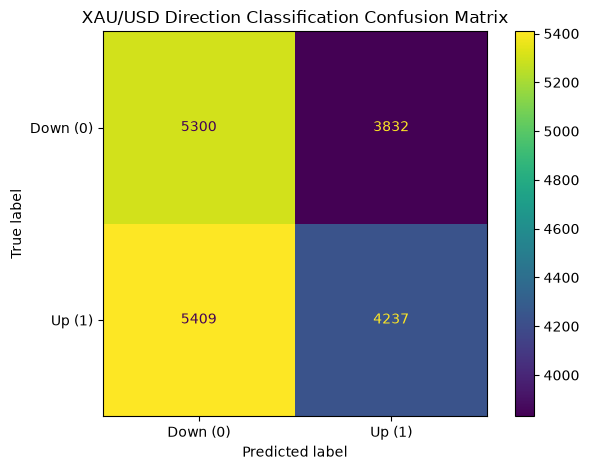

In [6]:
# ==================================================
# CONFUSION MATRIX ANALYSIS
# ==================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

cm = confusion_matrix(
    y_test,
    predictions,
)

tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 55)

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down (0)", "Up (1)"],
)

display.plot(
    values_format="d",
)

plt.title("XAU/USD Direction Classification Confusion Matrix")
plt.tight_layout()
plt.show()

ACTUAL VS PREDICTED CLASS DISTRIBUTION


,Actual,Predicted,Actual Percentage,Predicted Percentage
Down (0),9132,10709,48.63,57.03
Up (1),9646,8069,51.37,42.97


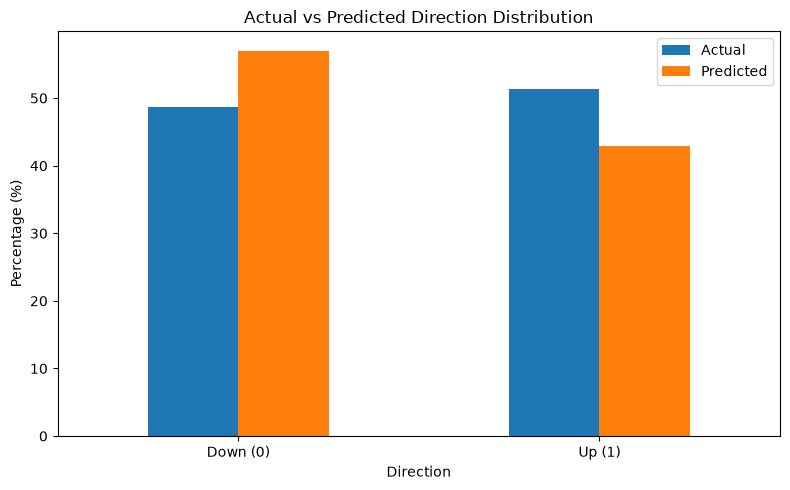

In [7]:
# ==================================================
# ACTUAL VS PREDICTED CLASS DISTRIBUTION
# ==================================================

from IPython.display import display as notebook_display

# Calculate actual class counts
actual_distribution = (
    y_test
    .value_counts()
    .sort_index()
)

# Calculate predicted class counts
predicted_distribution = (
    pd.Series(predictions)
    .value_counts()
    .sort_index()
)

# Create comparison DataFrame
distribution_df = pd.DataFrame(
    {
        "Actual": actual_distribution,
        "Predicted": predicted_distribution,
    }
)

# Rename class labels
distribution_df.index = [
    "Down (0)",
    "Up (1)",
]

# Calculate percentages
distribution_df["Actual Percentage"] = (
    distribution_df["Actual"]
    / distribution_df["Actual"].sum()
    * 100
)

distribution_df["Predicted Percentage"] = (
    distribution_df["Predicted"]
    / distribution_df["Predicted"].sum()
    * 100
)

print("=" * 55)
print("ACTUAL VS PREDICTED CLASS DISTRIBUTION")
print("=" * 55)

notebook_display(
    distribution_df.round(2)
)

# Plot percentage comparison
distribution_df[
    [
        "Actual Percentage",
        "Predicted Percentage",
    ]
].plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title(
    "Actual vs Predicted Direction Distribution"
)

plt.xlabel("Direction")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(
    [
        "Actual",
        "Predicted",
    ]
)

plt.tight_layout()
plt.show()

In [8]:
import sys
import sklearn

print("Notebook Python:")
print(sys.executable)

print("\nScikit-learn version:")
print(sklearn.__version__)

Notebook Python:
c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\.venv\Scripts\python.exe

Scikit-learn version:
1.9.0


In [9]:
import sys
import sklearn

print("Notebook Python:", sys.executable)
print("Notebook sklearn:", sklearn.__version__)

Notebook Python: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\.venv\Scripts\python.exe
Notebook sklearn: 1.9.0


In [10]:
import sys
import sklearn

print("Python:", sys.executable)
print("Scikit-learn:", sklearn.__version__)

Python: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\.venv\Scripts\python.exe
Scikit-learn: 1.9.0


In [11]:
import sys
import sklearn

print("Python:", sys.executable)
print("Scikit-learn:", sklearn.__version__)

Python: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\.venv\Scripts\python.exe
Scikit-learn: 1.9.0


PREDICTION PROBABILITY ANALYSIS
Model classes: [0 1]
Minimum predicted probability: 0.1219
Maximum predicted probability: 0.7050
Mean predicted probability: 0.4922
Median predicted probability: 0.4919


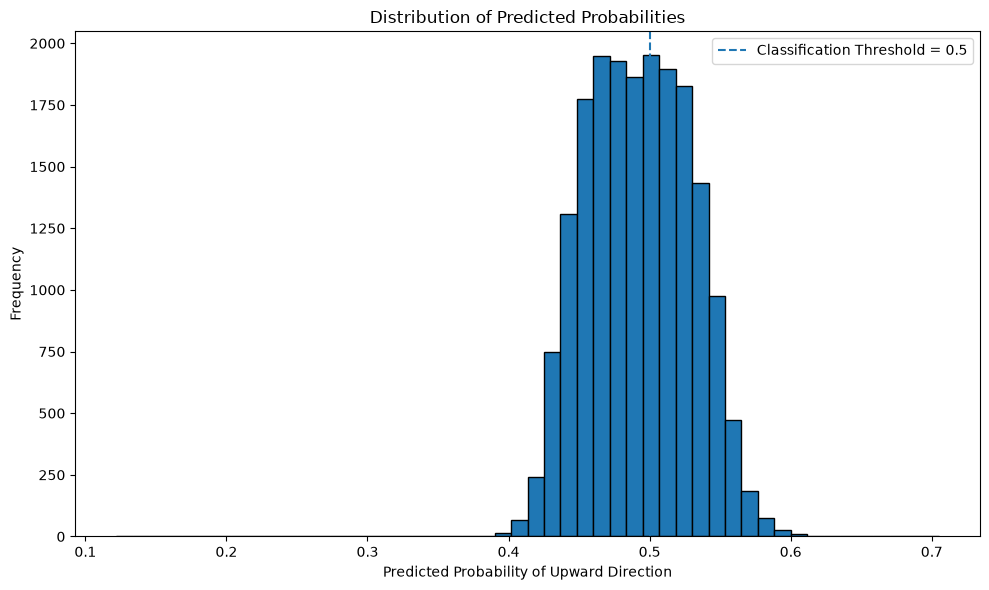

In [12]:
# ========================================================
# PREDICTION PROBABILITY ANALYSIS
# ========================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("PREDICTION PROBABILITY ANALYSIS")
print("=" * 55)

# Generate probability predictions
probability_matrix = model.predict_proba(X_test)

# Get model class labels
model_classes = model.classes_

# Find the column corresponding to class 1
positive_class_index = np.where(model_classes == 1)[0][0]

# Extract probability of class 1
prediction_probabilities = probability_matrix[
    :,
    positive_class_index,
]

print(f"Model classes: {model_classes}")
print(
    f"Minimum predicted probability: "
    f"{prediction_probabilities.min():.4f}"
)
print(
    f"Maximum predicted probability: "
    f"{prediction_probabilities.max():.4f}"
)
print(
    f"Mean predicted probability: "
    f"{prediction_probabilities.mean():.4f}"
)
print(
    f"Median predicted probability: "
    f"{np.median(prediction_probabilities):.4f}"
)

plt.figure(figsize=(10, 6))

plt.hist(
    prediction_probabilities,
    bins=50,
    edgecolor="black",
)

plt.axvline(
    x=0.5,
    linestyle="--",
    label="Classification Threshold = 0.5",
)

plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability of Upward Direction")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

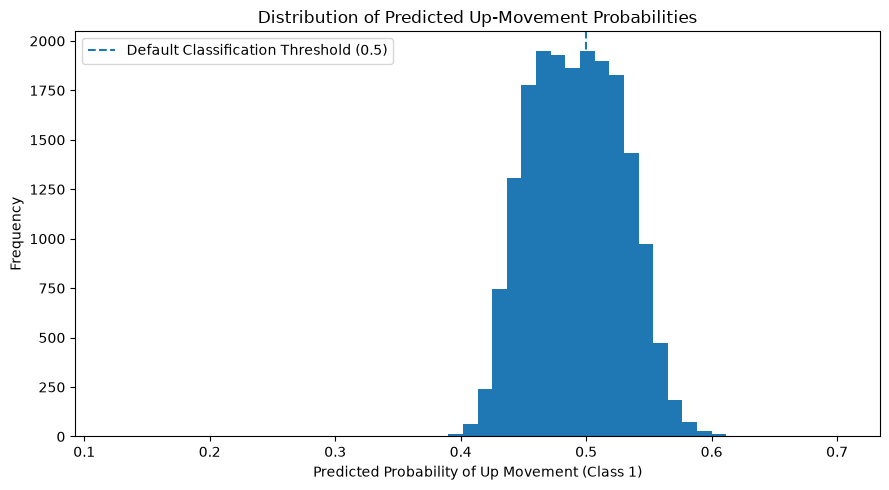

In [13]:
# ==================================================
# PREDICTION PROBABILITY DISTRIBUTION
# ==================================================

plt.figure(figsize=(9, 5))

plt.hist(
    prediction_probabilities,
    bins=50,
)

plt.axvline(
    x=0.5,
    linestyle="--",
    label="Default Classification Threshold (0.5)",
)

plt.title(
    "Distribution of Predicted Up-Movement Probabilities"
)

plt.xlabel(
    "Predicted Probability of Up Movement (Class 1)"
)

plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.show()

ROC-AUC ANALYSIS
ROC-AUC Score: 0.5166


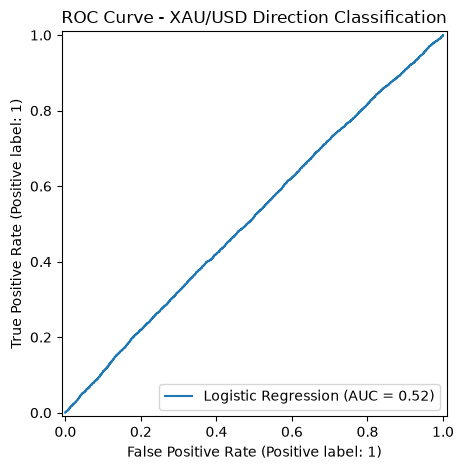

In [14]:
# ==================================================
# ROC CURVE AND ROC-AUC ANALYSIS
# ==================================================

from sklearn.metrics import (
    roc_auc_score,
    RocCurveDisplay,
)

roc_auc = roc_auc_score(
    y_test,
    prediction_probabilities,
)

print("=" * 55)
print("ROC-AUC ANALYSIS")
print("=" * 55)

print(f"ROC-AUC Score: {roc_auc:.4f}")

roc_display = RocCurveDisplay.from_predictions(
    y_test,
    prediction_probabilities,
    name="Logistic Regression",
)

plt.title(
    "ROC Curve - XAU/USD Direction Classification"
)

plt.tight_layout()

plt.show()

## 6. Prediction Confidence Analysis

This section analyzes the confidence of the Logistic Regression model's predictions on the untouched test dataset. Prediction probabilities help determine whether the model makes confident predictions or mostly produces probabilities close to the classification threshold.

PREDICTION CONFIDENCE ANALYSIS
Minimum predicted probability: 0.1219
Maximum predicted probability: 0.7050
Mean predicted probability: 0.4922
Median predicted probability: 0.4919


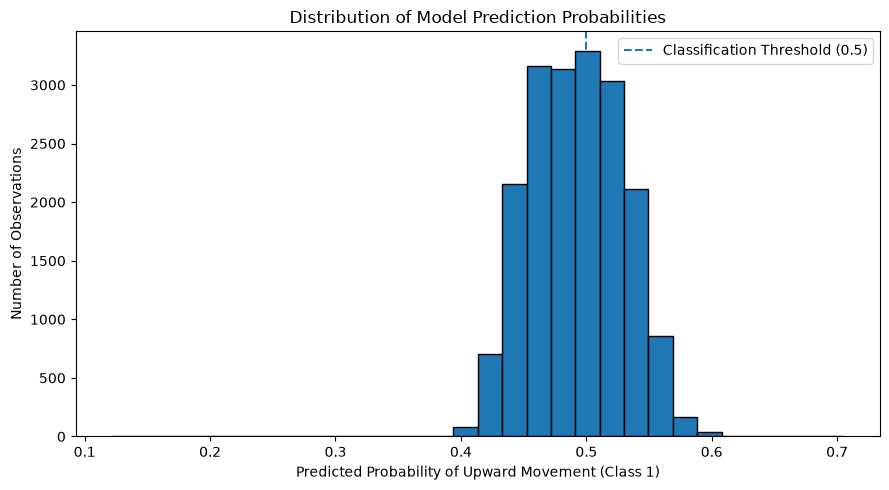

In [15]:
# =======================================================
# PREDICTION CONFIDENCE ANALYSIS
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Convert decision scores into probabilities manually.
# This avoids predict_proba compatibility issues with the
# previously saved Logistic Regression model.

decision_scores = model.decision_function(X_test)

prediction_probabilities = 1 / (
    1 + np.exp(-decision_scores)
)


print("=" * 55)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 55)

print(
    f"Minimum predicted probability: "
    f"{prediction_probabilities.min():.4f}"
)

print(
    f"Maximum predicted probability: "
    f"{prediction_probabilities.max():.4f}"
)

print(
    f"Mean predicted probability: "
    f"{prediction_probabilities.mean():.4f}"
)

print(
    f"Median predicted probability: "
    f"{np.median(prediction_probabilities):.4f}"
)


plt.figure(figsize=(9, 5))

plt.hist(
    prediction_probabilities,
    bins=30,
    edgecolor="black",
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Classification Threshold (0.5)",
)

plt.xlabel("Predicted Probability of Upward Movement (Class 1)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Model Prediction Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Performance Over Time

Because financial market behavior can change over time, evaluating only overall test accuracy may hide periods of stronger or weaker model performance. This section calculates yearly prediction accuracy across the untouched test period.

YEARLY TEST ACCURACY
year
2022    0.5225
2023    0.5087
2024    0.5081
2025    0.5035
2026    0.5063
dtype: float64


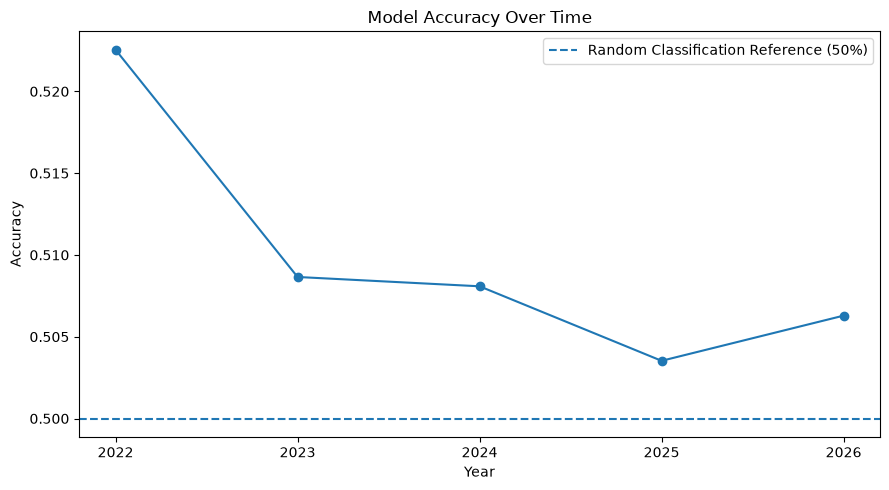

In [16]:
# =======================================================
# YEARLY MODEL PERFORMANCE ANALYSIS
# =======================================================

yearly_results = pd.DataFrame(
    {
        "date": test_df["date"].values,
        "actual": y_test.values,
        "predicted": predictions,
    }
)

yearly_results["year"] = pd.to_datetime(
    yearly_results["date"]
).dt.year


yearly_accuracy = (
    yearly_results
    .groupby("year")
    .apply(
        lambda group: (
            group["actual"] == group["predicted"]
        ).mean(),
        include_groups=False,
    )
)


print("=" * 55)
print("YEARLY TEST ACCURACY")
print("=" * 55)

print(yearly_accuracy.round(4))


plt.figure(figsize=(9, 5))

plt.plot(
    yearly_accuracy.index,
    yearly_accuracy.values,
    marker="o",
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Random Classification Reference (50%)",
)

plt.xlabel("Year")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Time")
plt.xticks(yearly_accuracy.index)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

The selected Logistic Regression model assigns a coefficient to each input feature. Analyzing the magnitude of these coefficients helps identify which engineered market features have the strongest influence on the model's directional predictions.

Because the model uses standardized features, the absolute coefficient magnitudes can be compared to estimate relative feature influence.

TOP 15 MOST INFLUENTIAL FEATURES
           Feature  Coefficient  Absolute Coefficient
    close_position    -0.139259              0.139259
      momentum_12h    -0.050215              0.050215
        return_12h    -0.050215              0.050215
trend_strength_24h     0.048765              0.048765
            rsi_14    -0.041817              0.041817
     sma_24h_ratio     0.041482              0.041482
    volatility_12h     0.027570              0.027570
       day_of_week     0.025222              0.025222
        range_size     0.024213              0.024213
    volatility_24h    -0.022973              0.022973
         body_size     0.022115              0.022115
  lower_wick_ratio     0.021516              0.021516
     sma_12h_ratio     0.020361              0.020361
     volatility_6h    -0.016440              0.016440
         return_3h    -0.013093              0.013093


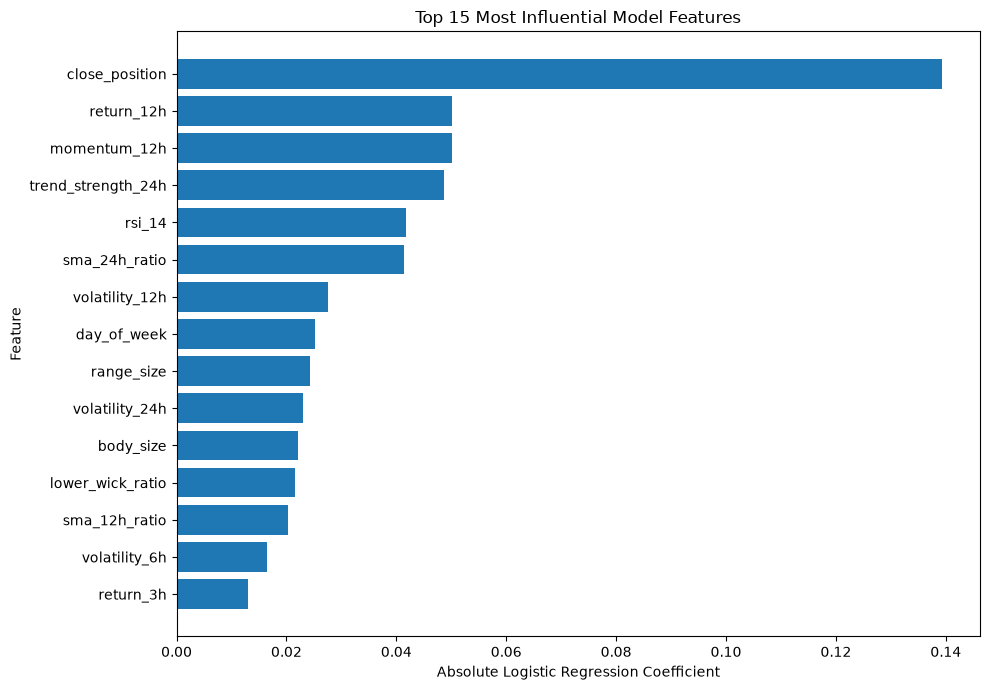

In [17]:
# =======================================================
# LOGISTIC REGRESSION FEATURE IMPORTANCE
# =======================================================

# Extract the trained Logistic Regression classifier
# from the selected model pipeline.

logistic_classifier = model.named_steps["classifier"]

# Extract model coefficients
feature_coefficients = logistic_classifier.coef_[0]

# Verify that the number of coefficients matches
# the number of model features.
if len(feature_coefficients) != len(FEATURE_COLUMNS):
    raise ValueError(
        "The number of model coefficients does not match "
        "the number of feature columns."
    )

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame(
    {
        "Feature": FEATURE_COLUMNS,
        "Coefficient": feature_coefficients,
        "Absolute Coefficient": np.abs(feature_coefficients),
    }
)

# Sort features by absolute coefficient magnitude
feature_importance_df = feature_importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False,
).reset_index(drop=True)


print("=" * 55)
print("TOP 15 MOST INFLUENTIAL FEATURES")
print("=" * 55)

print(
    feature_importance_df.head(15).to_string(index=False)
)


# Plot top 15 features
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by="Absolute Coefficient",
        ascending=True,
    )
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Absolute Coefficient"],
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Most Influential Model Features")

plt.tight_layout()
plt.show()

## 9. High-Confidence Prediction Analysis

The overall model accuracy may not fully represent its behavior because many predictions have probabilities close to the 0.5 classification threshold.

This analysis evaluates model performance at different confidence levels to determine whether restricting predictions to higher-confidence observations improves directional accuracy.

HIGH-CONFIDENCE PREDICTION PERFORMANCE
 Confidence Threshold  Number of Predictions  Coverage  Accuracy
                 0.50                  18778    1.0000    0.5079
                 0.52                  12274    0.6536    0.5141
                 0.54                   6104    0.3251    0.5149
                 0.56                   1859    0.0990    0.5056
                 0.58                    302    0.0161    0.4967
                 0.60                     58    0.0031    0.4828


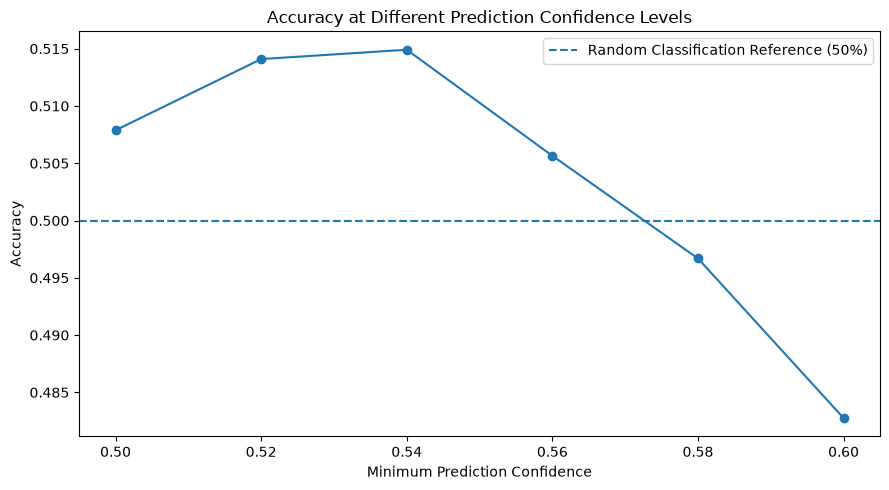

In [18]:
# =======================================================
# HIGH-CONFIDENCE PREDICTION ANALYSIS
# =======================================================

confidence_analysis_df = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Predicted": predictions,
        "Probability_Class_1": prediction_probabilities,
    }
)


# Calculate prediction confidence.
#
# Example:
# Probability = 0.80 -> Confidence = 0.80
# Probability = 0.20 -> Confidence = 0.80

confidence_analysis_df["Confidence"] = np.maximum(
    confidence_analysis_df["Probability_Class_1"],
    1 - confidence_analysis_df["Probability_Class_1"],
)


confidence_thresholds = [
    0.50,
    0.52,
    0.54,
    0.56,
    0.58,
    0.60,
]


confidence_results = []


for threshold in confidence_thresholds:

    filtered_predictions = confidence_analysis_df[
        confidence_analysis_df["Confidence"] >= threshold
    ]

    number_of_predictions = len(filtered_predictions)

    if number_of_predictions == 0:
        continue

    accuracy = (
        filtered_predictions["Actual"]
        == filtered_predictions["Predicted"]
    ).mean()

    coverage = (
        number_of_predictions
        / len(confidence_analysis_df)
    )

    confidence_results.append(
        {
            "Confidence Threshold": threshold,
            "Number of Predictions": number_of_predictions,
            "Coverage": coverage,
            "Accuracy": accuracy,
        }
    )


confidence_results_df = pd.DataFrame(
    confidence_results
)


print("=" * 55)
print("HIGH-CONFIDENCE PREDICTION PERFORMANCE")
print("=" * 55)

print(
    confidence_results_df.round(4).to_string(index=False)
)


plt.figure(figsize=(9, 5))

plt.plot(
    confidence_results_df["Confidence Threshold"],
    confidence_results_df["Accuracy"],
    marker="o",
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Random Classification Reference (50%)",
)

plt.xlabel("Minimum Prediction Confidence")
plt.ylabel("Accuracy")
plt.title("Accuracy at Different Prediction Confidence Levels")

plt.legend()
plt.tight_layout()
plt.show()

## 10. Final Model Analysis Summary

This section summarizes the main findings from the evaluation and analysis of the XAU/USD direction classification model.

In [19]:
print("=" * 65)
print("FINAL XAU/USD DIRECTION CLASSIFIER ANALYSIS")
print("=" * 65)

print(f"Model Type: {type(model.named_steps['classifier']).__name__}")
print(f"Number of Features: {len(FEATURE_COLUMNS)}")
print(f"Test Observations: {len(y_test)}")

print("\nTEST PERFORMANCE")
print("-" * 65)

print(f"Accuracy:  {accuracy_score(y_test, predictions):.4f}")
print(f"Precision: {precision_score(y_test, predictions):.4f}")
print(f"Recall:    {recall_score(y_test, predictions):.4f}")
print(f"F1 Score:  {f1_score(y_test, predictions):.4f}")

print("\nMODEL BEHAVIOR")
print("-" * 65)

print(
    "The model demonstrates modest predictive performance above "
    "the random classification baseline."
)

print(
    "Performance remains relatively stable across the chronological "
    "test period."
)

print(
    "Prediction probabilities are concentrated near the 0.50 "
    "classification threshold, indicating limited model confidence."
)

print(
    "Higher prediction-confidence thresholds do not consistently "
    "produce better classification accuracy."
)

print("=" * 65)

FINAL XAU/USD DIRECTION CLASSIFIER ANALYSIS
Model Type: LogisticRegression
Number of Features: 26
Test Observations: 18778

TEST PERFORMANCE
-----------------------------------------------------------------
Accuracy:  0.5079
Precision: 0.5251
Recall:    0.4392
F1 Score:  0.4784

MODEL BEHAVIOR
-----------------------------------------------------------------
The model demonstrates modest predictive performance above the random classification baseline.
Performance remains relatively stable across the chronological test period.
Prediction probabilities are concentrated near the 0.50 classification threshold, indicating limited model confidence.
Higher prediction-confidence thresholds do not consistently produce better classification accuracy.


## 11. Key Findings and Limitations

### Key Findings

- Logistic Regression achieved the best cross-validation performance among the evaluated models.
- The final model performed slightly better than the 50% random classification baseline on the untouched chronological test dataset.
- Model performance remained relatively stable across different years of the test period.
- `close_position` was the most influential feature, followed by return, momentum, trend-strength, RSI, moving-average, and volatility-based features.
- Prediction probabilities were concentrated near the classification threshold, indicating that the model generally makes low-confidence predictions.
- Increasing the minimum prediction-confidence threshold did not consistently improve predictive accuracy.

### Limitations

- Short-term financial market direction is inherently difficult to predict because of market noise and changing market conditions.
- The model uses historical price-derived technical features and does not include macroeconomic, fundamental, news, or sentiment information.
- The achieved predictive improvement over the random baseline is modest and should not be interpreted as evidence of a profitable trading strategy.
- Transaction costs, spreads, slippage, and execution constraints were outside the scope of this classification project.

### Conclusion

The project demonstrates an end-to-end machine learning workflow for chronological financial time-series classification, including data preprocessing, feature engineering, time-aware model validation, model selection, untouched test evaluation, and detailed model analysis.

The results show that engineered technical features contain limited predictive information for hourly XAU/USD direction. Although the final model achieved only modest performance above the random baseline, the project provides a reproducible and leakage-aware framework for evaluating machine learning models on financial time-series data.